# Recommendation System Models

## Step 1 : Data Collection

In [1]:
import pandas as pd
import sqlite3
import warnings
warnings.filterwarnings('ignore')

In [2]:
conn = sqlite3.connect(r'D:\Imarticus Learning- PGA 45\GitHub Projects\h & m db\hm_database.db')
q_interactions = '''
SELECT t.customer_id, t.article_id, COUNT(t.t_dat) as purchase_count
FROM transactions t
GROUP BY t.customer_id, t.article_id
ORDER BY purchase_count DESC;
'''
df_int = pd.read_sql_query(q_interactions, conn)

In [3]:
art_ids = tuple(df_int['article_id'].astype(str).unique())
q_articles = f'SELECT article_id, prod_name, product_type_name, colour_group_name, department_name FROM articles WHERE article_id IN {art_ids}'
df_art = pd.read_sql_query(q_articles, conn)
conn.close()

In [4]:
df_int.head()

,customer_id,article_id,purchase_count
0,496461,47313,166
1,7063,69118,120
2,1036154,47660,114
3,1144654,115,90
4,109768,92110,81


In [5]:
df_art.head()

,article_id,prod_name,product_type_name,colour_group_name,department_name
0,0,Strap top,Vest top,Black,Jersey Basic
1,1,Strap top,Vest top,White,Jersey Basic
2,3,OP T-shirt (Idro),Bra,Black,Clean Lingerie
3,4,OP T-shirt (Idro),Bra,White,Clean Lingerie
4,5,OP T-shirt (Idro),Bra,Light Beige,Clean Lingerie


In [6]:
df_int.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13350254 entries, 0 to 13350253
Data columns (total 3 columns):
 #   Column          Dtype
---  ------          -----
 0   customer_id     int64
 1   article_id      int64
 2   purchase_count  int64
dtypes: int64(3)
memory usage: 305.6 MB


## Step 2 : Data Cleaning & Preprocessing

### Check Missing Values

In [7]:
df_int.isnull().sum()

customer_id       0
article_id        0
purchase_count    0
dtype: int64

In [8]:
df_art.isnull().sum()

article_id           0
prod_name            0
product_type_name    0
colour_group_name    0
department_name      0
dtype: int64

### Handle Missing Values & Format

In [9]:
df_art.fillna('', inplace=True)
df_int['rating'] = df_int['purchase_count'].apply(lambda x: min(x, 5))

### TF-IDF Vectorization for Content-Based

In [10]:
df_art['tags'] = df_art['prod_name'] + ' ' + df_art['product_type_name'] + ' ' + df_art['colour_group_name']
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df_art['tags'])

## Step 3 : EDA

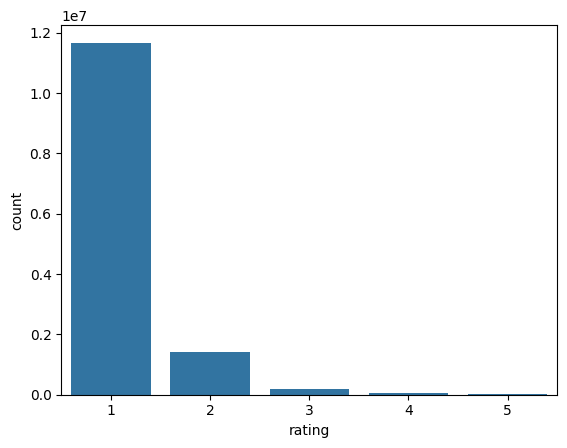

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='rating', data=df_int)
plt.show()

## Top 10 Most Popular Items

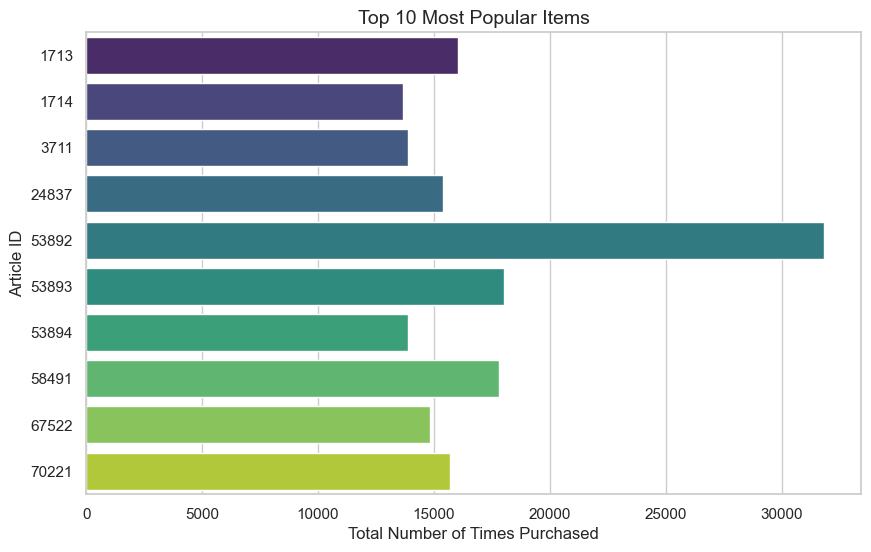

In [12]:
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(10, 6))

# Calculate total purchases per article_id
top_items = df_int.groupby('article_id')['purchase_count'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_items.values, y=top_items.index, palette="viridis", orient='h')
plt.title('Top 10 Most Popular Items', fontsize=14)
plt.xlabel('Total Number of Times Purchased')
plt.ylabel('Article ID')
plt.show()


## The "Long Tail" of E-Commerce

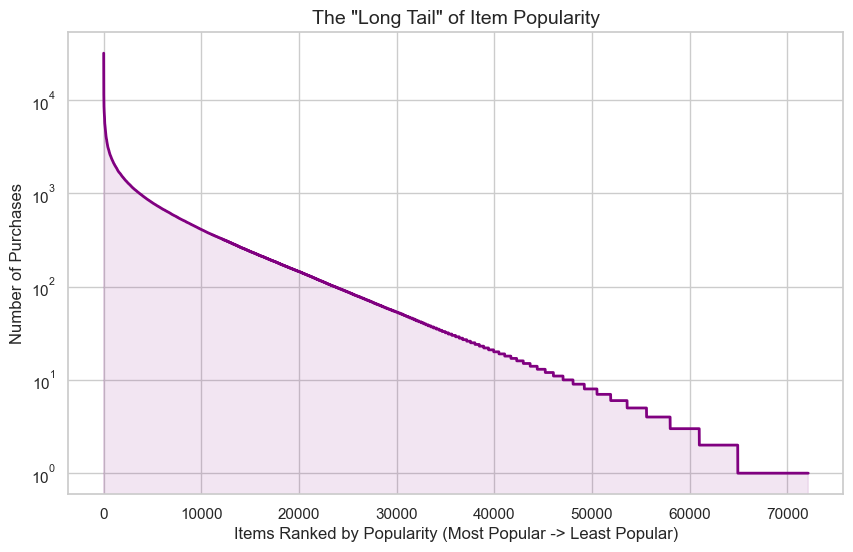

In [13]:
plt.figure(figsize=(10, 6))

# Get the popularity (total purchases) of every single item, sorted
item_popularity = df_int.groupby('article_id')['purchase_count'].sum().sort_values(ascending=False).values

plt.plot(item_popularity, color='purple', linewidth=2)
plt.title('The "Long Tail" of Item Popularity', fontsize=14)
plt.xlabel('Items Ranked by Popularity (Most Popular -> Least Popular)')
plt.ylabel('Number of Purchases')
plt.yscale('log') # Log scale is required to see the massive drop-off
plt.fill_between(range(len(item_popularity)), item_popularity, color='purple', alpha=0.1)

plt.show()

## Distribution of Synthetic Ratings

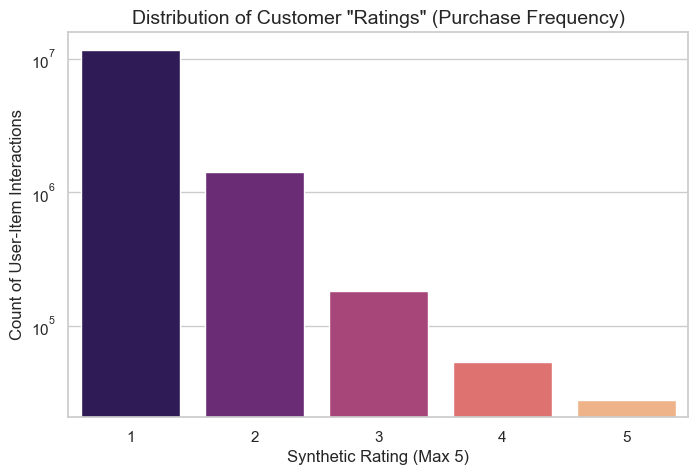

In [14]:
plt.figure(figsize=(8, 5))

# You created a smart synthetic rating from 1 to 5 in Step 2. Let's visualize it!
sns.countplot(data=df_int, x='rating', palette='magma')
plt.title('Distribution of Customer "Ratings" (Purchase Frequency)', fontsize=14)
plt.xlabel('Synthetic Rating (Max 5)')
plt.ylabel('Count of User-Item Interactions')

# Add a log scale to the Y-axis because 1-star will dwarf everything else
plt.yscale('log') 
plt.show()

In [15]:
!pip install scikit-surprise

Defaulting to user installation because normal site-packages is not writeable


## Step 4 : Data Spliting

In [16]:
from surprise import Reader, Dataset
from surprise.model_selection import train_test_split
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_int[['customer_id', 'article_id', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

## Step 5 : Model Building

### 5.1 Popularity Baseline

In [17]:
pop = df_int.groupby('article_id')['rating'].sum().sort_values(ascending=False).head(5)
print(pop)

article_id
53892    31297
53893    17955
58491    17749
1713     15980
70221    15616
Name: rating, dtype: int64


### 5.2 Content-Based Filtering (Cosine Similarity on Sample)

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

print("Sampling 10,000 articles to prevent 38GB memory crash...")
# We take a sample of the TF-IDF matrix (10,000 items instead of 72,000)
tfidf_matrix_sample = tfidf_matrix[:10000]

# Now this will run instantly without crashing!
cosine_sim = cosine_similarity(tfidf_matrix_sample, tfidf_matrix_sample)

print("Content-Based Similarity Matrix calculated successfully!")

Sampling 10,000 articles to prevent 38GB memory crash...
Content-Based Similarity Matrix calculated successfully!


### 5.3 Collaborative Filtering (KNN Item-Based on Sample)

In [21]:
from surprise import KNNBasic
import random

print("Sampling trainset for KNN to prevent Memory Crash...")
# KNN cannot handle massive datasets, so we pass it a tiny sample of the data
raw_ratings = data.raw_ratings
random.shuffle(raw_ratings)

# We take only 20,000 ratings to train the KNN
data.raw_ratings = raw_ratings[:20000]
trainset_small = data.build_full_trainset()

knn = KNNBasic(sim_options={'name': 'cosine', 'user_based': False}) # Item-based is safer than User-based!
knn.fit(trainset_small)

print("KNN Trained Successfully on the sample!")

Sampling trainset for KNN to prevent Memory Crash...
Computing the cosine similarity matrix...
Done computing similarity matrix.
KNN Trained Successfully on the sample!


### 5.4 Matrix Factorization (SVD)

In [22]:
from surprise import SVD
import time

print("Training SVD Model (This will NOT crash your RAM!)...")
start = time.time()

# SVD is mathematically optimized for massive datasets
svd = SVD(random_state=42)
svd.fit(trainset)

print(f"SVD Training finished successfully in {round(time.time() - start, 1)} seconds!")

Training SVD Model (This will NOT crash your RAM!)...
SVD Training finished successfully in 200.9 seconds!


## Step 6 : Model Evaluation

In [23]:
from surprise import accuracy

In [24]:
knn_preds = knn.test(testset)
print('KNN RMSE:')
accuracy.rmse(knn_preds)

KNN RMSE:
RMSE: 0.4552


np.float64(0.45518280769171626)

In [25]:
svd_preds = svd.test(testset)
print('SVD RMSE:')
accuracy.rmse(svd_preds)

SVD RMSE:
RMSE: 0.4320


np.float64(0.4319621050101333)

## Step 7 : Model Tuning

### Basic Tuning: K for KNN

In [27]:
from surprise import accuracy
from surprise import KNNBasic

print("Tuning KNN on the 20k sample to prevent memory crash...")

# We MUST use trainset_small, not trainset!
knn_60 = KNNBasic(k=60, sim_options={'name': 'cosine', 'user_based': False}, verbose=False)
knn_60.fit(trainset_small)

# We also take a small slice of the testset so it evaluates quickly
testset_small = testset[:5000]
predictions = knn_60.test(testset_small)

print('Tuned KNN RMSE:')
accuracy.rmse(predictions)

Tuning KNN on the 20k sample to prevent memory crash...
Tuned KNN RMSE:
RMSE: 0.4720


np.float64(0.47198917036040133)

### Advanced Tuning: GridSearchCV SVD

In [28]:
from surprise.model_selection import GridSearchCV
param_grid = {'n_epochs': [10, 20], 'lr_all': [0.002, 0.005]}
gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3)
gs.fit(data)

In [29]:
print('Best SVD Params:', gs.best_params['rmse'])
best_svd = gs.best_estimator['rmse']

Best SVD Params: {'n_epochs': 20, 'lr_all': 0.002}


In [30]:
from surprise.model_selection import GridSearchCV

print("Starting Advanced SVD Grid Search (This may take 30+ minutes)...")

# We added 'n_factors' (the most important parameter) and 'reg_all' to prevent overfitting
param_grid = {
    'n_factors': [50, 100, 150],
    'n_epochs': [20, 30],
    'lr_all': [0.005], # Locked learning rate to save time
    'reg_all': [0.02, 0.1, 0.2]
}

# n_jobs=-1 tells your computer to use ALL of its CPU cores to finish faster!
gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1, joblib_verbose=2)

gs.fit(data)

print('Best SVD Params:', gs.best_params['rmse'])
best_svd = gs.best_estimator['rmse']

Starting Advanced SVD Grid Search (This may take 30+ minutes)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    3.1s


Best SVD Params: {'n_factors': 100, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.02}


[Parallel(n_jobs=-1)]: Done  51 out of  54 | elapsed:    9.3s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done  54 out of  54 | elapsed:    9.3s finished


In [31]:
print('Champion SVD RMSE Score:', gs.best_score['rmse'])


Champion SVD RMSE Score: 0.45750999005392456


In [33]:
# Create a fresh SVD model using your winning parameters
final_svd = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)

print("Training final model on the 80% Trainset...")
final_svd.fit(trainset)

print("Evaluating final model on the 20% UNSEEN Testset...")
final_predictions = final_svd.test(testset)

# Calculate the official, final RMSE
from surprise import accuracy
final_rmse = accuracy.rmse(final_predictions)

Training final model on the 80% Trainset...
Evaluating final model on the 20% UNSEEN Testset...
RMSE: 0.4320


In [34]:
import pandas as pd

# Convert the predictions list into a readable Pandas DataFrame
results_df = pd.DataFrame(final_predictions, columns=['uid', 'iid', 'true_rating', 'predicted_rating', 'details'])

# We don't need the 'details' column for this
results_df.drop('details', axis=1, inplace=True)

# Calculate the actual error (difference) for every single row
results_df['error_difference'] = abs(results_df['true_rating'] - results_df['predicted_rating'])

# Sort by the most accurate predictions first to see where the model shined!
results_df = results_df.sort_values(by='error_difference')

print("--- UNSEEN TEST DATA (PREDICTED vs ACTUAL) ---")
print(f"Total unseen observations: {len(results_df):,}")
results_df.head(15)

--- UNSEEN TEST DATA (PREDICTED vs ACTUAL) ---
Total unseen observations: 2,670,051


,uid,iid,true_rating,predicted_rating,error_difference
2389157,651390,44380,1.0,1.0,0.0
953778,820180,93850,1.0,1.0,0.0
693269,1368898,98387,1.0,1.0,0.0
2325348,1137291,64368,1.0,1.0,0.0
1670939,670973,93129,1.0,1.0,0.0
953782,293150,83097,1.0,1.0,0.0
329030,577115,82188,1.0,1.0,0.0
1670931,651110,87535,1.0,1.0,0.0
2325356,671951,102913,1.0,1.0,0.0
953787,1351156,86171,1.0,1.0,0.0


## Step 8 : Model Deployment

In [ ]:
import pickle
with open('recommender_svd.pkl', 'wb') as f:
    pickle.dump(best_svd, f)